### $w^{g\gamma}(\theta)$, $w^{g\gamma}|_S(\theta)$ measurements

### Import needed pkgs

In [1]:
import os
os.environ['OMP_NUM_THREADS'] = '1'

In [2]:
import numpy as np
from matplotlib import pyplot as plt

In [3]:
import treecorr
from astropy.table import Table

In [4]:
import healpy as hp

In [5]:
import pyccl as ccl

In [6]:
cosmo_ccl = ccl.CosmologyVanillaLCDM()

### Measurements with treecorr

In [34]:
data = Table.read("data/cata/tomo_1.0-1.3.fits")

In [35]:
data = data[::50]

In [36]:
r3d = ccl.comoving_angular_distance(cosmo_ccl, a=1./(1+data['zp']))

In [37]:
%%time
tc_fore = treecorr.Catalog(ra=data['ra'], dec=data['dec'], r=r3d, ra_units='degress', dec_units='degrees', patch_centers="patch_centers.txt")

CPU times: user 833 ms, sys: 0 ns, total: 833 ms
Wall time: 55.8 ms


In [41]:
tc_back = treecorr.Catalog(ra=data['ra'], dec=data['dec'], r=r3d , g1=data['e1'], g2=-data['e2'], ra_units='degress', dec_units='degrees', patch_centers="patch_centers.txt")

In [13]:
def ang2rperp(ang, zmean, cosmo):
    return ccl.comoving_angular_distance(
        cosmo, 
        a=1./(1+zmean)
    )*np.deg2rad(ang/60.)

In [14]:
def rperp2ang(rperp, zmean, cosmo):
    return np.rad2deg(rperp/ccl.comoving_angular_distance(
        cosmo, 
        a=1./(1+zmean)
    )) * 60

In [23]:
rperp_min = ang2rperp(0.5, zmean=1.15, cosmo=cosmo_ccl)

In [22]:
rperp2ang(0.5551, zmean=1.15, cosmo=cosmo_ccl)

0.5000067557811051

In [24]:
rperp_max = ang2rperp(60, zmean=1.15, cosmo=cosmo_ccl)

In [21]:
rperp2ang(66.6111, zmean=1.15, cosmo=cosmo_ccl)

60.00000001803416

In [26]:
ng_corr = treecorr.NGCorrelation(min_sep=rperp_min, max_sep=rperp_max, nbins=7, 
                                 metric='Rperp',
                                 num_threads=16, 
                                 var_method='jackknife', cross_patch_weight='match')

In [32]:
ng_S_corr = treecorr.NGCorrelation(min_sep=0.3807, max_sep=45.6878, nbins=7, 
                                 metric='Rperp', max_rpar=0,
                                 num_threads=16, 
                                 var_method='jackknife', cross_patch_weight='match')

In [39]:
%%time
ng_corr.process(tc_fore, tc_back)

CPU times: user 1min 19s, sys: 640 ms, total: 1min 20s
Wall time: 4.83 s


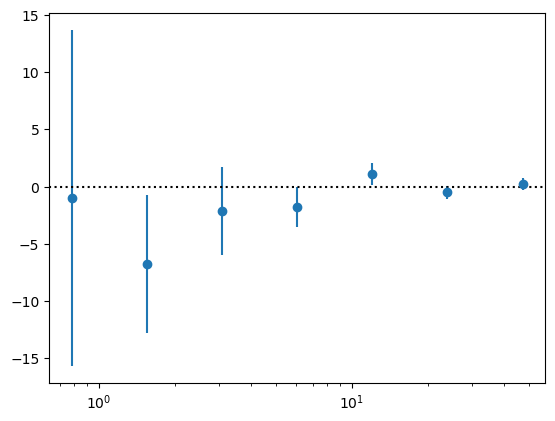

In [40]:
plt.errorbar(ng_corr.rnom, ng_corr.xi*1e4, np.sqrt(ng_corr.varxi)*1e4, fmt='o')
plt.axhline(0, c='k', ls=':')
plt.semilogx();

In [30]:
import pickle
with open("results/tomo_0.6-0.8_ngcorr.pkl", "wb") as f:
    pickle.dump(ng_corr, f)

In [33]:
%%time
ng_S_corr.process(tc_fore, tc_back)

CPU times: user 4h 17min 41s, sys: 1.48 s, total: 4h 17min 43s
Wall time: 16min 10s


In [34]:
import pickle
with open("results/tomo_0.6-0.8_ngScorr.pkl", "wb") as f:
    pickle.dump(ng_S_corr, f)

In [17]:
%%time
tc_fore2 = treecorr.Catalog(ra=data_ds['ra'], dec=data_ds['dec'], ra_units='degress', dec_units='degrees', npatch=128)

CPU times: user 22.7 s, sys: 1.44 s, total: 24.1 s
Wall time: 1.69 s


In [18]:
tc_back2 = treecorr.Catalog(ra=data_ds['ra'], dec=data_ds['dec'], g1=data_ds['e1'], g2=-data_ds['e2'], ra_units='degress', dec_units='degrees', patch_centers=tc_fore2.patch_centers)

In [19]:
ng_corr2 = treecorr.NGCorrelation(min_sep=1.0, max_sep=300.0, nbins=15,
                                  sep_units='arcmin',
                                 num_threads=16, 
                                 var_method='jackknife', cross_patch_weight='match')

In [20]:
%%time
ng_corr2.process(tc_fore2, tc_back2)

CPU times: user 1min 43s, sys: 3.23 s, total: 1min 46s
Wall time: 10.4 s


(1, 300)

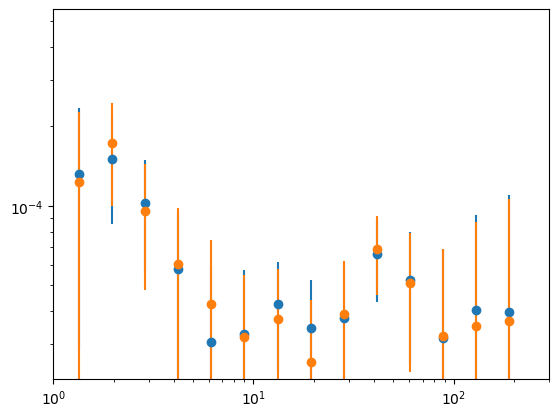

In [21]:
plt.errorbar(ng_corr.rnom, ng_corr.xi, np.sqrt(ng_corr.varxi), fmt='o')
plt.errorbar(ccl.comoving_angular_distance(cosmo_ccl, a=1./(1+0.7))*np.deg2rad(ng_corr2.rnom/60), ng_corr2.xi, np.sqrt(ng_corr2.varxi), fmt='o')
# plt.errorbar(theta_bin, gammat, gammat_err, fmt='ok')
plt.loglog()
plt.xlim(1, 300)